# Checkpoint 1: Dataset Selection & Initial EDA

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# load the data
df = pd.read_csv('/content/drive/MyDrive/housing.csv')
df.head()

# look at the data before anything else
print("Shape:", df.shape)
print("\nNull Values:\n", df.isnull().sum())
print("\nSummary Stats:")
df.describe()

# the raw room/bedroom counts are at the block level which isn't that useful
# dividing by households gives us per-unit ratios that actually mean something
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# check the categorical variable
df['ocean_proximity'].value_counts()

# color palette for plots
sns.set_theme(style='whitegrid', palette='muted')
BLUE = '#2563EB'
ORANGE = '#F59E0B'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (20640, 10)

Null Values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Summary Stats:


# Checkpoint 2: Preprocessing & Model Development

In [8]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

BLUE = '#2563EB'
ORANGE = '#F59E0B'

In [13]:
# Load and prep (feature engineering)

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/housing.csv')

# fix nulls before doing any calculations that use total_bedrooms
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# now safe to engineer features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

y = df['median_house_value']
X = df.drop(columns=['median_house_value'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train size: (16512, 15)
Test size: (4128, 15)


In [15]:
# Linear regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression")
print(f"  RMSE: ${lr_rmse:,.0f}")
print(f"  MAE:  ${lr_mae:,.0f}")
print(f"  R²:   {lr_r2:.3f}")

Linear Regression
  RMSE: $72,669
  MAE:  $50,889
  R²:   0.597


In [17]:
# Random forest

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest")
print(f"  RMSE: ${rf_rmse:,.0f}")
print(f"  MAE:  ${rf_mae:,.0f}")
print(f"  R²:   {rf_r2:.3f}")

Random Forest
  RMSE: $50,331
  MAE:  $32,329
  R²:   0.807


In [19]:
# Comparison

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE':  [lr_rmse, rf_rmse],
    'MAE':   [lr_mae, rf_mae],
    'R²':    [lr_r2, rf_r2]
})
comparison

,Model,RMSE,MAE,R²
0,Linear Regression,72668.538379,50888.660016,0.597018
1,Random Forest,50330.947164,32329.317706,0.806686


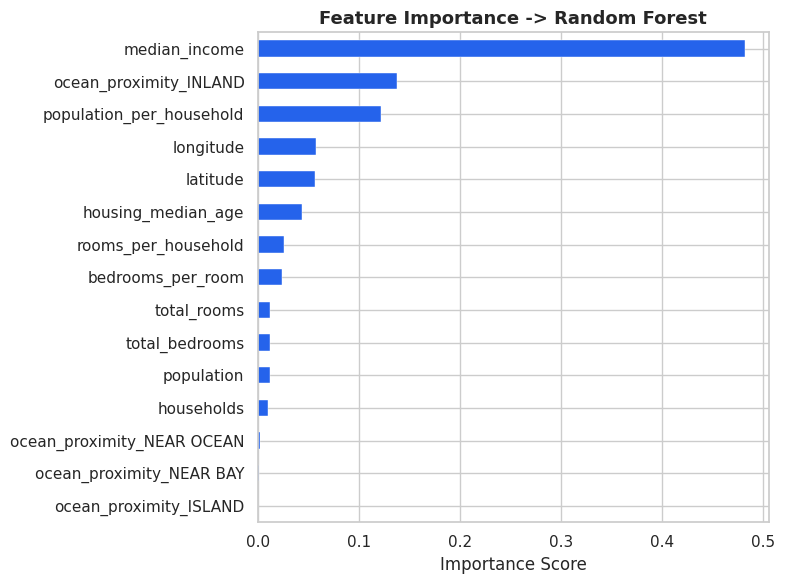

In [22]:
# Feature Importance

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color=BLUE, edgecolor='white', linewidth=0.3)
ax.set_title('Feature Importance -> Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

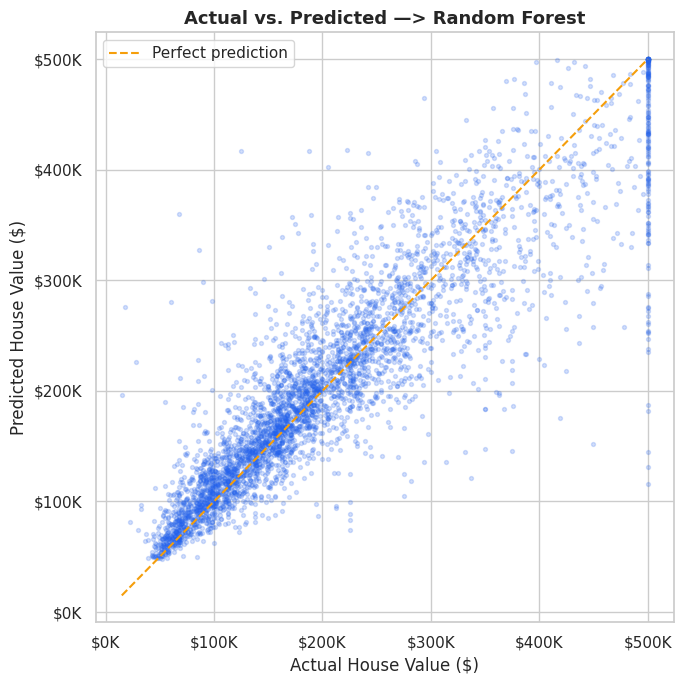

In [23]:
# Actual vs Predicted

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, rf_preds, alpha=0.2, s=8, color=BLUE)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color=ORANGE, linewidth=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual House Value ($)')
ax.set_ylabel('Predicted House Value ($)')
ax.set_title('Actual vs. Predicted —> Random Forest', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()